In [12]:
import dataset_prov as ds
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Cargamos el dataset (pedimos energía y ID del cubelet)
ds_all = ds.build_dataset("../Data/All", max_files=20, primary_only=False, target=["energy", "cublet"])

photon_counts = []
energies = []
cublet_ids = []

# 2. Bucle único para extraer todo a la vez
for d in ds_all:
    # d[0] son los fotones (matriz timesteps x sensors), la sumamos
    total_photons = d[0].numpy().sum()
    photon_counts.append(total_photons)
    
    # d[1] contiene la tupla (energía, ID) porque lo pedimos en 'target'
    energy, cid = d[1]
    energies.append(energy)
    cublet_ids.append(cid)

# 3. Convertimos a arrays rápidos de numpy
a_photons = np.array(photon_counts)
a_energy  = np.array(energies)
a_ids     = np.array(cublet_ids).astype(int)

# 4. Decodificamos las coordenadas
a_z = a_ids // 100
a_y = (a_ids % 100) // 10
a_x = a_ids % 10

print(f"✅ ¡Lectura completada! {len(a_ids)} cubelets procesados en memoria.")
print(f"   -> Máximo de fotones: {a_photons.max():.0f}")
print(f"   -> Energía máxima: {a_energy.max():.2f} MeV")

✅ ¡Lectura completada! 42742 cubelets procesados en memoria.
   -> Máximo de fotones: 19974044
   -> Energía máxima: 23314.64 MeV


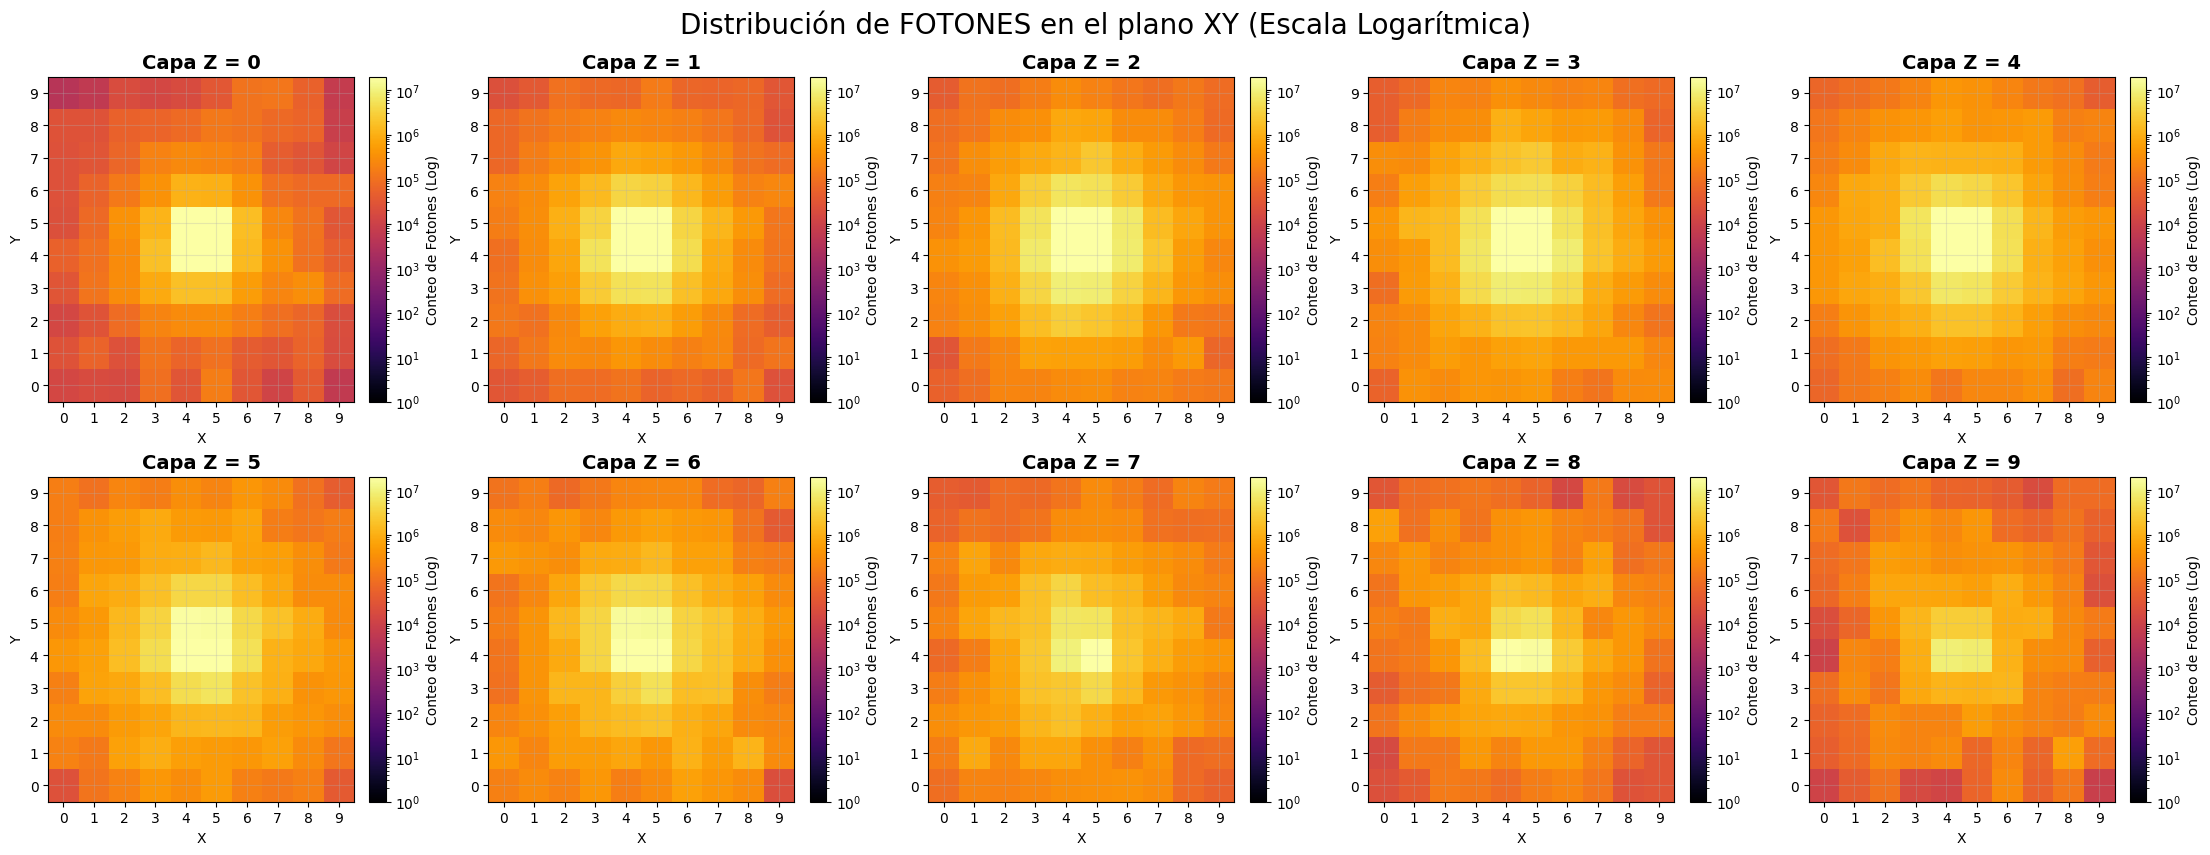

In [13]:
# --- GRÁFICO 1: FOTONES ---
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(22, 8), constrained_layout=True)
axes = axes.flatten()

mask_positivos_p = a_photons > 0
min_photons = a_photons[mask_positivos_p].min() if mask_positivos_p.any() else 1
max_photons = a_photons.max()

for z in range(10):
    ax = axes[z]
    mask = (a_z == z)
    
    h = ax.hist2d(a_x[mask], a_y[mask], weights=a_photons[mask], 
                  bins=[np.arange(11)-0.5, np.arange(11)-0.5], 
                  cmap='inferno', norm=LogNorm(vmin=min_photons, vmax=max_photons))
    
    ax.set_title(f"Capa Z = {z}", fontsize=14, fontweight='bold')
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.grid(alpha=0.3)
    fig.colorbar(h[3], ax=ax, label='Conteo de Fotones (Log)')

plt.suptitle("Distribución de FOTONES en el plano XY (Escala Logarítmica)", fontsize=20, y=1.05)
plt.show()

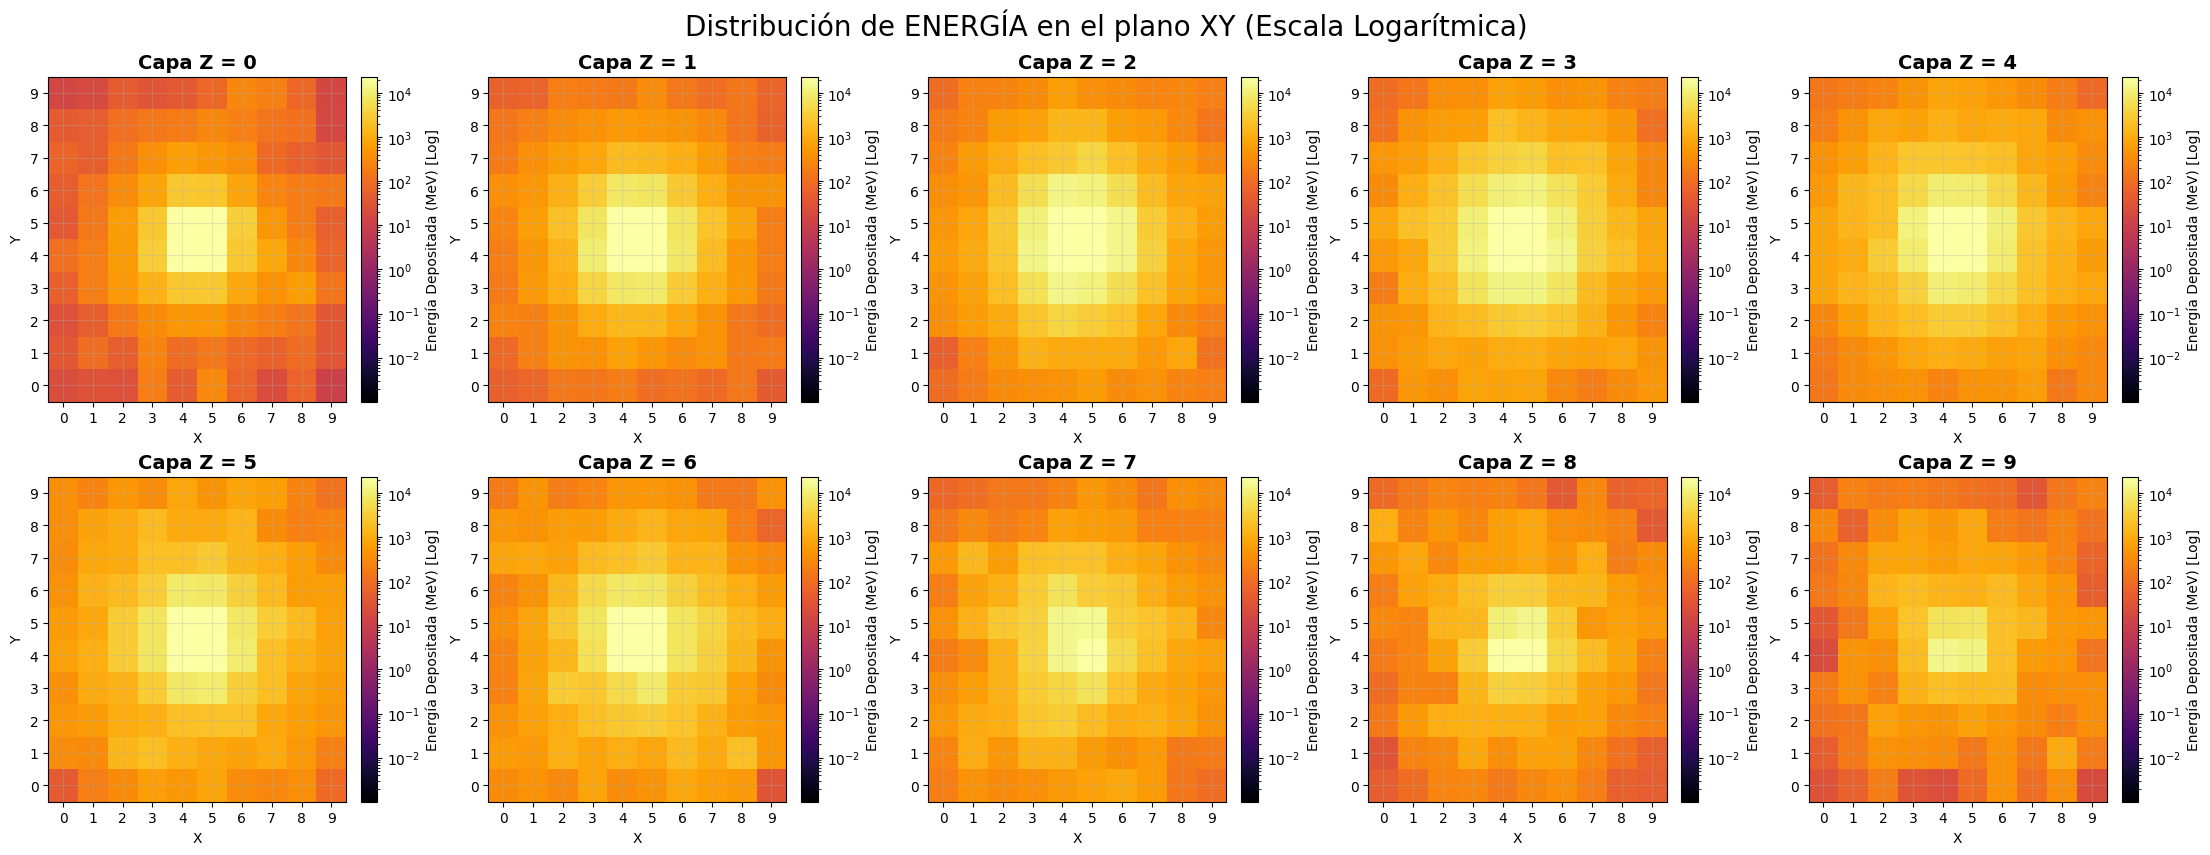

In [14]:
# --- GRÁFICO 2: ENERGÍA ---
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(22, 8), constrained_layout=True)
axes = axes.flatten()

mask_positivos_e = a_energy > 0
min_energy = a_energy[mask_positivos_e].min() if mask_positivos_e.any() else 1e-3
max_energy = a_energy.max()

for z in range(10):
    ax = axes[z]
    mask = (a_z == z)
    
    h = ax.hist2d(a_x[mask], a_y[mask], weights=a_energy[mask], 
                  bins=[np.arange(11)-0.5, np.arange(11)-0.5], 
                  cmap='inferno', norm=LogNorm(vmin=min_energy, vmax=max_energy))
    
    ax.set_title(f"Capa Z = {z}", fontsize=14, fontweight='bold')
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.grid(alpha=0.3)
    fig.colorbar(h[3], ax=ax, label='Energía Depositada (MeV) [Log]')

plt.suptitle("Distribución de ENERGÍA en el plano XY (Escala Logarítmica)", fontsize=20, y=1.05)
plt.show()